**Nama : Achmad Baharuddin Akbar**

**NIM  : 210411100001**

# Test fuzzy c-means 1

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal
0,"Soroti Kekurangan Nakes, Prabowo Minta India K...","Kamis, 21 Nov 2024 09:31 WIB",Jakarta - Presiden Republik Indonesia Prabowo ...,Kesehatan,Jakarta Presiden Republik Indonesia Prabowo S...,jakarta presiden republik indonesia prabowo s...,"['jakarta', 'presiden', 'republik', 'indonesia...",jakarta presiden republik indonesia prabowo su...
1,Mayapada Hospital Bisa Tangani Bengkak Pasca T...,"Kamis, 21 Nov 2024 09:06 WIB",Jakarta - Mayapada Hospital menawarkan solusi ...,Kesehatan,Jakarta Mayapada Hospital menawarkan solusi p...,jakarta mayapada hospital menawarkan solusi p...,"['jakarta', 'mayapada', 'hospital', 'menawarka...",jakarta mayapada hospital menawarkan solusi pe...
2,"Jangan Sampai Keliru, Ini Beda Nyeri Punggung ...","Kamis, 21 Nov 2024 09:01 WIB",Jakarta - Saraf kejepit menjadi suatu masalah ...,Kesehatan,Jakarta Saraf kejepit menjadi suatu masalah y...,jakarta saraf kejepit menjadi suatu masalah y...,"['jakarta', 'saraf', 'kejepit', 'menjadi', 'su...",jakarta saraf kejepit diabaikan berdampak seri...
3,"Heboh Pejabat di Swedia Punya Fobia Aneh, Taku...","Kamis, 21 Nov 2024 08:31 WIB",Jakarta - Seorang menteri Swedia yang punya ke...,Kesehatan,Jakarta Seorang menteri Swedia yang punya ket...,jakarta seorang menteri swedia yang punya ket...,"['jakarta', 'seorang', 'menteri', 'swedia', 'y...",jakarta menteri swedia ketakutan pisang bahan ...
4,Mayapada Hospital Punya Teknologi VABB untuk B...,"Kamis, 21 Nov 2024 08:14 WIB",Jakarta - Mayapada Hospital menawarkan teknolo...,Kesehatan,Jakarta Mayapada Hospital menawarkan teknolog...,jakarta mayapada hospital menawarkan teknolog...,"['jakarta', 'mayapada', 'hospital', 'menawarka...",jakarta mayapada hospital menawarkan teknologi...


In [16]:
!pip install scikit-fuzzy
# Import libraries yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

In [17]:
texts = df['Filtering/stopword removal']

In [18]:
# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

In [19]:
# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tfidf_array)

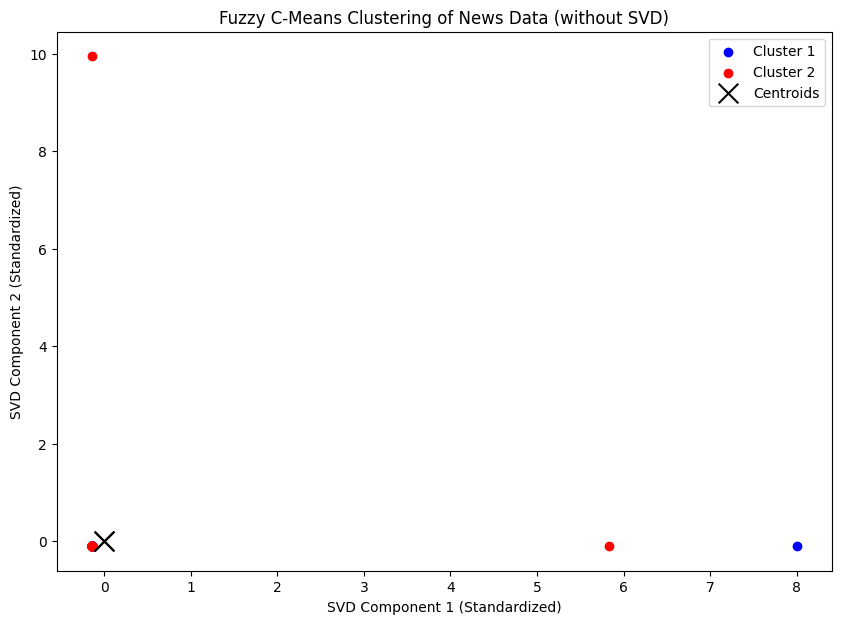

In [20]:
n_clusters = 2  # Jumlah cluster yang diinginkan
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_scaled.T, c=n_clusters, m=2, error=0.001, maxiter=1000, init=None
)

# Menentukan cluster untuk setiap data berdasarkan keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']
for i in range(n_clusters):
    plt.scatter(X_scaled[cluster_labels == i, 0], X_scaled[cluster_labels == i, 1],
                color=colors[i], label=f'Cluster {i+1}')

# Menampilkan pusat cluster
plt.scatter(cntr[:, 0], cntr[:, 1], marker='x', s=200, color='k', label='Centroids')

plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering of News Data (without SVD)')
plt.legend()
plt.show()

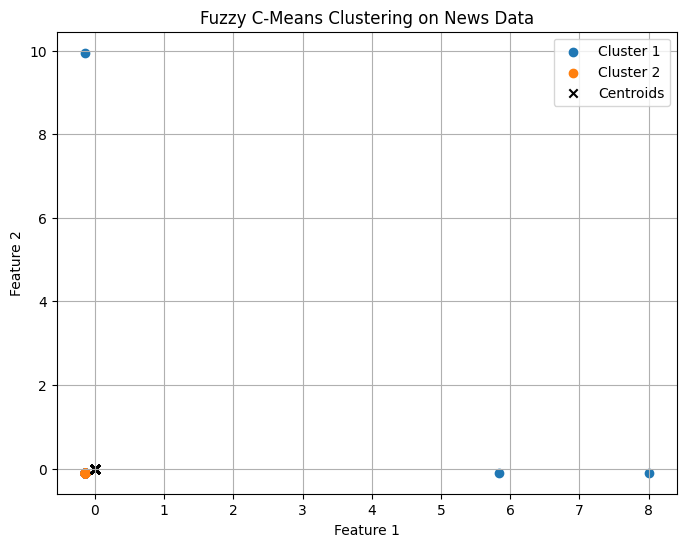

Fuzzy Partition Coefficient (FPC): 0.5000000000014934


In [21]:
# Tentukan jumlah cluster dan parameter fuzziness
n_clusters = 2
m = 2  # Parameter fuzziness

# Terapkan Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, n_clusters, m, error=0.001, maxiter=1000, init=None
)

# Tentukan keanggotaan cluster
cluster_membership = np.argmax(u, axis=0)

# Visualisasi Hasil Clustering
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(X_scaled[cluster_membership == i, 0], X_scaled[cluster_membership == i, 1], label=f'Cluster {i+1}')

# Tampilkan centroid
plt.scatter(cntr[0], cntr[1], marker='x', color='black', label='Centroids')

plt.title('Fuzzy C-Means Clustering on News Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Evaluasi Hasil
print("Fuzzy Partition Coefficient (FPC):", fpc)


# Test fuzzy c-means 2

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal
0,"Soroti Kekurangan Nakes, Prabowo Minta India K...","Kamis, 21 Nov 2024 09:31 WIB",Jakarta - Presiden Republik Indonesia Prabowo ...,Kesehatan,Jakarta Presiden Republik Indonesia Prabowo S...,jakarta presiden republik indonesia prabowo s...,"['jakarta', 'presiden', 'republik', 'indonesia...",jakarta presiden republik indonesia prabowo su...
1,Mayapada Hospital Bisa Tangani Bengkak Pasca T...,"Kamis, 21 Nov 2024 09:06 WIB",Jakarta - Mayapada Hospital menawarkan solusi ...,Kesehatan,Jakarta Mayapada Hospital menawarkan solusi p...,jakarta mayapada hospital menawarkan solusi p...,"['jakarta', 'mayapada', 'hospital', 'menawarka...",jakarta mayapada hospital menawarkan solusi pe...
2,"Jangan Sampai Keliru, Ini Beda Nyeri Punggung ...","Kamis, 21 Nov 2024 09:01 WIB",Jakarta - Saraf kejepit menjadi suatu masalah ...,Kesehatan,Jakarta Saraf kejepit menjadi suatu masalah y...,jakarta saraf kejepit menjadi suatu masalah y...,"['jakarta', 'saraf', 'kejepit', 'menjadi', 'su...",jakarta saraf kejepit diabaikan berdampak seri...
3,"Heboh Pejabat di Swedia Punya Fobia Aneh, Taku...","Kamis, 21 Nov 2024 08:31 WIB",Jakarta - Seorang menteri Swedia yang punya ke...,Kesehatan,Jakarta Seorang menteri Swedia yang punya ket...,jakarta seorang menteri swedia yang punya ket...,"['jakarta', 'seorang', 'menteri', 'swedia', 'y...",jakarta menteri swedia ketakutan pisang bahan ...
4,Mayapada Hospital Punya Teknologi VABB untuk B...,"Kamis, 21 Nov 2024 08:14 WIB",Jakarta - Mayapada Hospital menawarkan teknolo...,Kesehatan,Jakarta Mayapada Hospital menawarkan teknolog...,jakarta mayapada hospital menawarkan teknolog...,"['jakarta', 'mayapada', 'hospital', 'menawarka...",jakarta mayapada hospital menawarkan teknologi...


In [60]:
!pip install scikit-fuzzy
# Import libraries yang diperlukan
import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
!pip install fuzzy-c-means

In [61]:
texts = df['Filtering/stopword removal']

In [62]:
# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

# Convert to pandas DataFrame
tfidf_df = pd.DataFrame(tfidf_array, columns=tfidf.get_feature_names_out())

# Save to CSV
tfidf_df.to_csv("tfidf_output.csv", index=False)

tfidf_df

,abad,abai,abis,ablasi,abnormal,abu,academy,acara,ade,adenomyosis,...,youtuber,yuan,yudi,yutaka,yuwono,zaitun,zaizai,zat,zatzat,zoonosis
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.032806,0.0,0.0
96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.087865,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [63]:
# Normalisasi dengan StandardScaler
scaler = StandardScaler()
data_2d_normalized = scaler.fit_transform(tfidf_array)

In [64]:
from sklearn.metrics import silhouette_score
from fcmeans import FCM  # Pastikan Anda menginstal fcmeans
from sklearn.decomposition import TruncatedSVD

# Iterasi n_components
best_silhouette = -1
best_n_components = 0
results = {}

for n in range(2, 50):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(tfidf_array)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=2.0, max_iter=100, error=0.001, random_state=42)
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score
    score = silhouette_score(data_reduced, cluster_labels)
    results[n] = score

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette Score={score}")

    # Perbarui nilai terbaik
    if score > best_silhouette:
        best_silhouette = score
        best_n_components = n

# Hasil akhir
print(f"\nBest n_components: {best_n_components} with silhouette score: {best_silhouette}")

Iterasi dengan n_components=2: Silhouette Score=0.40856181984841394
Iterasi dengan n_components=3: Silhouette Score=0.4465009214065138
Iterasi dengan n_components=4: Silhouette Score=0.43999356098206666
Iterasi dengan n_components=5: Silhouette Score=0.2092383864320869
Iterasi dengan n_components=6: Silhouette Score=0.1778239390579134
Iterasi dengan n_components=7: Silhouette Score=0.15411641290428146
Iterasi dengan n_components=8: Silhouette Score=0.14917393198445425
Iterasi dengan n_components=9: Silhouette Score=0.13195414527492405
Iterasi dengan n_components=10: Silhouette Score=0.11687429146129484
Iterasi dengan n_components=11: Silhouette Score=0.10880964186583006
Iterasi dengan n_components=12: Silhouette Score=0.09466137621579832
Iterasi dengan n_components=13: Silhouette Score=0.1016451991347767
Iterasi dengan n_components=14: Silhouette Score=0.08701194828754391
Iterasi dengan n_components=15: Silhouette Score=0.08370616992769238
Iterasi dengan n_components=16: Silhouette Sco

In [65]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels

# Menampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
print("Jumlah data pada setiap cluster:")
print(cluster_counts)

df_filtered = df[['judul', 'tanggal', 'isi', 'kategori', 'Cluster']]
df_filtered

Jumlah data pada setiap cluster:
Cluster
1    62
0    38
Name: count, dtype: int64


,judul,tanggal,isi,kategori,Cluster
0,"Soroti Kekurangan Nakes, Prabowo Minta India K...","Kamis, 21 Nov 2024 09:31 WIB",Jakarta - Presiden Republik Indonesia Prabowo ...,Kesehatan,1
1,Mayapada Hospital Bisa Tangani Bengkak Pasca T...,"Kamis, 21 Nov 2024 09:06 WIB",Jakarta - Mayapada Hospital menawarkan solusi ...,Kesehatan,1
2,"Jangan Sampai Keliru, Ini Beda Nyeri Punggung ...","Kamis, 21 Nov 2024 09:01 WIB",Jakarta - Saraf kejepit menjadi suatu masalah ...,Kesehatan,1
3,"Heboh Pejabat di Swedia Punya Fobia Aneh, Taku...","Kamis, 21 Nov 2024 08:31 WIB",Jakarta - Seorang menteri Swedia yang punya ke...,Kesehatan,1
4,Mayapada Hospital Punya Teknologi VABB untuk B...,"Kamis, 21 Nov 2024 08:14 WIB",Jakarta - Mayapada Hospital menawarkan teknolo...,Kesehatan,1
...,...,...,...,...,...
95,Jijik! Supermarket Ini Penuh Bangkai Tikus dan...,"Selasa, 19 Nov 2024 17:00 WIB",Jakarta - Supermarket seharusnya bersih. Tetap...,Kuliner,1
96,"Mike Tyson Tetap Bugar di Usia 58 Tahun, Ini M...","Selasa, 19 Nov 2024 16:30 WIB",Jakarta - Mike Tyson kembali menyorot perhatia...,Kuliner,1
97,5 Pengunjung Resto Ini Kena Denda Puluhan Juta...,"Selasa, 19 Nov 2024 16:00 WIB",Jakarta - Karena dipicu berbagai alasan dan se...,Kuliner,1
98,Canggih! Kini Susu Basi Bisa Dideteksi via Pon...,"Selasa, 19 Nov 2024 15:00 WIB",Jakarta - Kecanggihan teknologi kini membuat d...,Kuliner,1


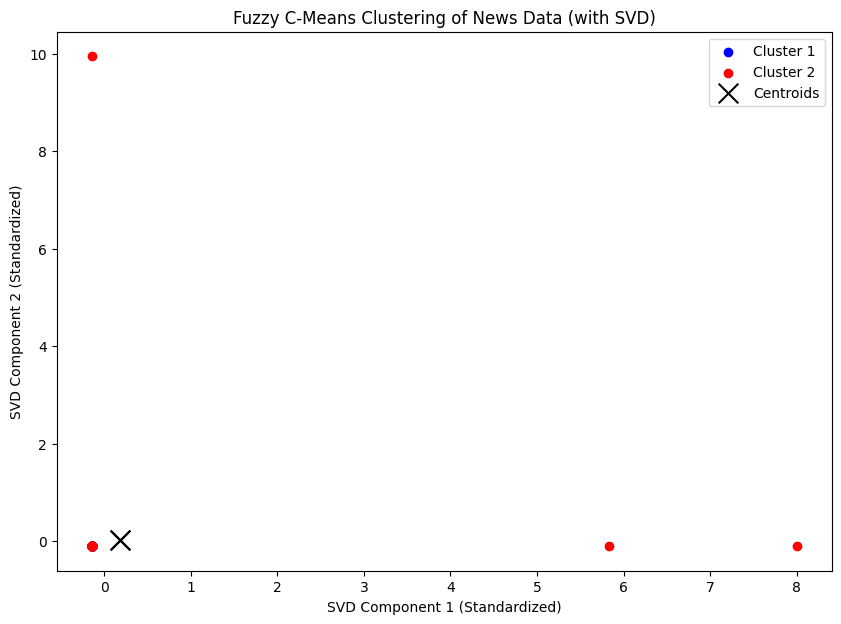

In [66]:
cntr = fcm.centers  # Pusat cluster

# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']  # Warna untuk masing-masing cluster
for i in range(2):  # Iterasi berdasarkan jumlah cluster
    plt.scatter(
        data_2d_normalized[cluster_labels == i, 0],  # Sumbu x
        data_2d_normalized[cluster_labels == i, 1],  # Sumbu y
        color=colors[i],
        label=f'Cluster {i + 1}'
    )

# Menampilkan pusat cluster
plt.scatter(
    cntr[:, 0], cntr[:, 1],
    marker='x', s=200, color='k', label='Centroids'
)

plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering of News Data (with SVD)')
plt.legend()
plt.show()


<ipython-input-67-09d5def57a7d>:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


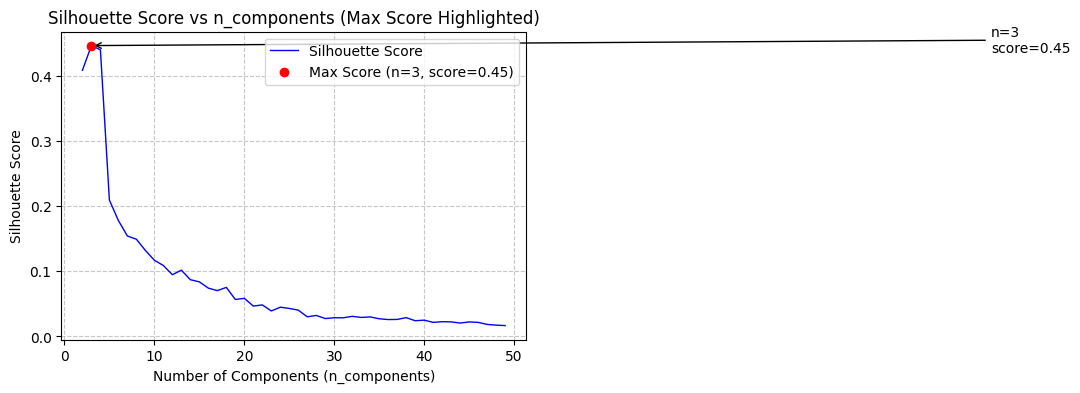

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Urutkan hasil berdasarkan n_components (ascending) untuk grafik mulus
sorted_results = sorted(results.items())  # Hanya diurutkan berdasarkan n_components
n_components_sorted = [item[0] for item in sorted_results]
scores_sorted = [item[1] for item in sorted_results]

# Cari skor tertinggi
max_score_index = np.argmax(scores_sorted)
max_n_components = n_components_sorted[max_score_index]
max_score = scores_sorted[max_score_index]

# Buat line chart
plt.figure(figsize=(6, 4))
plt.plot(n_components_sorted, scores_sorted, label='Silhouette Score', color='blue', linewidth=1)
plt.scatter(max_n_components, max_score, color='red', zorder=5, label=f'Max Score (n={max_n_components}, score={max_score:.2f})')

# Tambahkan anotasi pada skor tertinggi
plt.annotate(f"n={max_n_components}\nscore={max_score:.2f}",
             xy=(max_n_components, max_score),
             xytext=(max_n_components + 100, max_score - 0.01),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

# Label dan judul
plt.xlabel("Number of Components (n_components)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs n_components (Max Score Highlighted)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [68]:
# Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=20, random_state=42)
data_2d = svd.fit_transform(tfidf_array)

data_2d.shape

(100, 20)

In [69]:
# Tetapkan random seed u
np.random.seed(42)

# Fuzzy C-Means Clustering
n_clusters = 2
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data_2d_normalized.T, c=n_clusters, m=2, error=0.001, maxiter=500, init=None
)

# Menentukan cluster untuk setiap data berdasarkan keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

In [70]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels

# Menampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
print("Jumlah data pada setiap cluster:")
print(cluster_counts)

df_filtered = df[['judul', 'tanggal', 'isi', 'kategori', 'Cluster']]
df_filtered




Jumlah data pada setiap cluster:
Cluster
1    52
0    48
Name: count, dtype: int64


,judul,tanggal,isi,kategori,Cluster
0,"Soroti Kekurangan Nakes, Prabowo Minta India K...","Kamis, 21 Nov 2024 09:31 WIB",Jakarta - Presiden Republik Indonesia Prabowo ...,Kesehatan,0
1,Mayapada Hospital Bisa Tangani Bengkak Pasca T...,"Kamis, 21 Nov 2024 09:06 WIB",Jakarta - Mayapada Hospital menawarkan solusi ...,Kesehatan,1
2,"Jangan Sampai Keliru, Ini Beda Nyeri Punggung ...","Kamis, 21 Nov 2024 09:01 WIB",Jakarta - Saraf kejepit menjadi suatu masalah ...,Kesehatan,0
3,"Heboh Pejabat di Swedia Punya Fobia Aneh, Taku...","Kamis, 21 Nov 2024 08:31 WIB",Jakarta - Seorang menteri Swedia yang punya ke...,Kesehatan,0
4,Mayapada Hospital Punya Teknologi VABB untuk B...,"Kamis, 21 Nov 2024 08:14 WIB",Jakarta - Mayapada Hospital menawarkan teknolo...,Kesehatan,1
...,...,...,...,...,...
95,Jijik! Supermarket Ini Penuh Bangkai Tikus dan...,"Selasa, 19 Nov 2024 17:00 WIB",Jakarta - Supermarket seharusnya bersih. Tetap...,Kuliner,0
96,"Mike Tyson Tetap Bugar di Usia 58 Tahun, Ini M...","Selasa, 19 Nov 2024 16:30 WIB",Jakarta - Mike Tyson kembali menyorot perhatia...,Kuliner,1
97,5 Pengunjung Resto Ini Kena Denda Puluhan Juta...,"Selasa, 19 Nov 2024 16:00 WIB",Jakarta - Karena dipicu berbagai alasan dan se...,Kuliner,1
98,Canggih! Kini Susu Basi Bisa Dideteksi via Pon...,"Selasa, 19 Nov 2024 15:00 WIB",Jakarta - Kecanggihan teknologi kini membuat d...,Kuliner,1


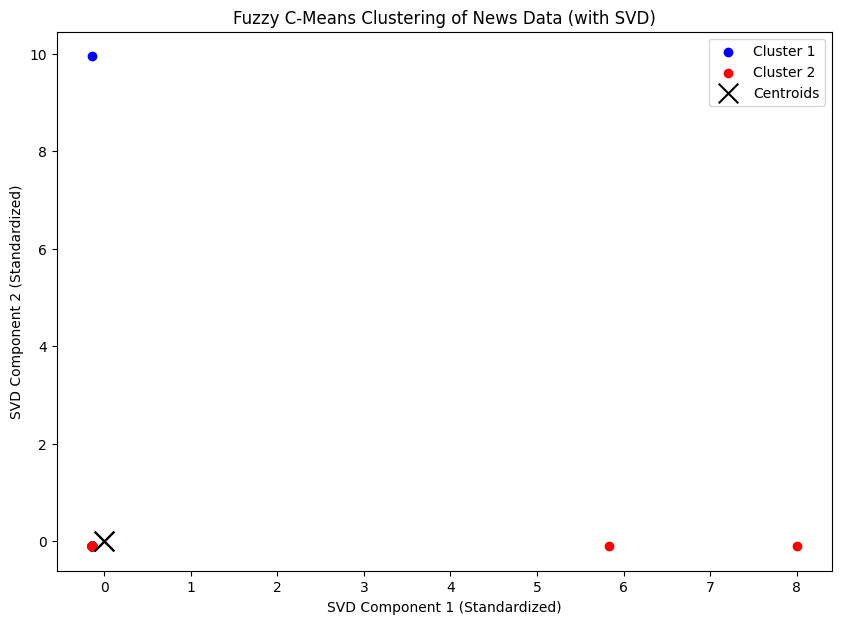

In [71]:
# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']
for i in range(n_clusters):
    plt.scatter(data_2d_normalized[cluster_labels == i, 0], data_2d_normalized[cluster_labels == i, 1],
                color=colors[i], label=f'Cluster {i+1}')

# Menampilkan pusat cluster
plt.scatter(cntr[:, 0], cntr[:, 1], marker='x', s=200, color='k', label='Centroids')

plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering of News Data (with SVD)')
plt.legend()
plt.show()

# Test fuzzy c-means 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
df.head()

In [ ]:
!pip install scikit-fuzzy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
import skfuzzy as fuzz

In [ ]:
# Lakukan preprocessing data menggunakan TF-IDF
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['Filtering/stopword removal']).toarray()

In [ ]:
lda = LatentDirichletAllocation(n_components=9)
X_topic = lda.fit_transform(X)

In [ ]:
# Implementasikan Fuzzy C-Means menggunakan Fuzzy library
n_clusters = 2
m = 8  # Fuzzy coefficient
max_iter = 1000
tol = 0.05

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X_topic.T, n_clusters, m, max_iter, tol)

# Dapatkan label cluster untuk setiap data
labels = np.argmax(u, axis=0)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Buat plot scatter
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    cluster_data = X_topic[labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {i}')
plt.scatter(cntr[:, 0], cntr[:, 1], s=100, c='red', marker='*', label='Cluster Centers')
plt.title('Fuzzy C-Means Clustering Scatter Plot')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()